# EDA: Twitter Sentiment Analysis (Hate Speech) - Варіант 19

Первинний аналіз даних для виявлення расистських/сексистських твітів.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/raw")
data_file = DATA_PATH / "train.csv"
if not data_file.exists():
    data_file = Path("../sample_data/train_sample.csv")
df = pd.read_csv(data_file)
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## Типи даних та пропуски

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [3]:
df.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

## Розподіл цільової змінної (Target Distribution)

In [4]:
label_col = 'label' if 'label' in df.columns else 'Label'
df[label_col].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

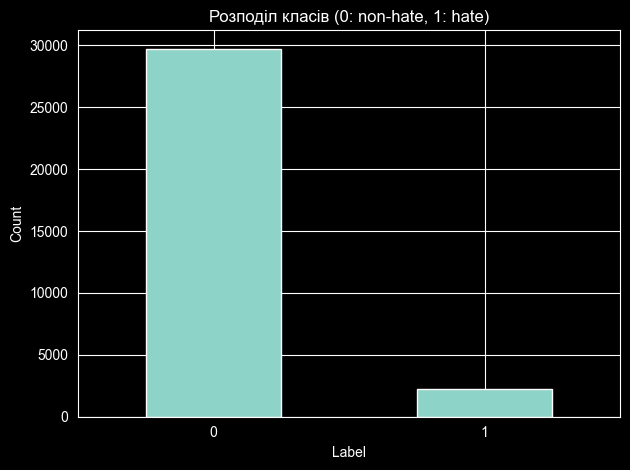

In [5]:
df[label_col].value_counts().plot(kind='bar')
plt.title('Розподіл класів (0: non-hate, 1: hate)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Довжина твітів

In [6]:
text_col = 'tweet' if 'tweet' in df.columns else 'Tweet'
df['word_count'] = df[text_col].astype(str).str.split().str.len()
df['char_count'] = df[text_col].astype(str).str.len()

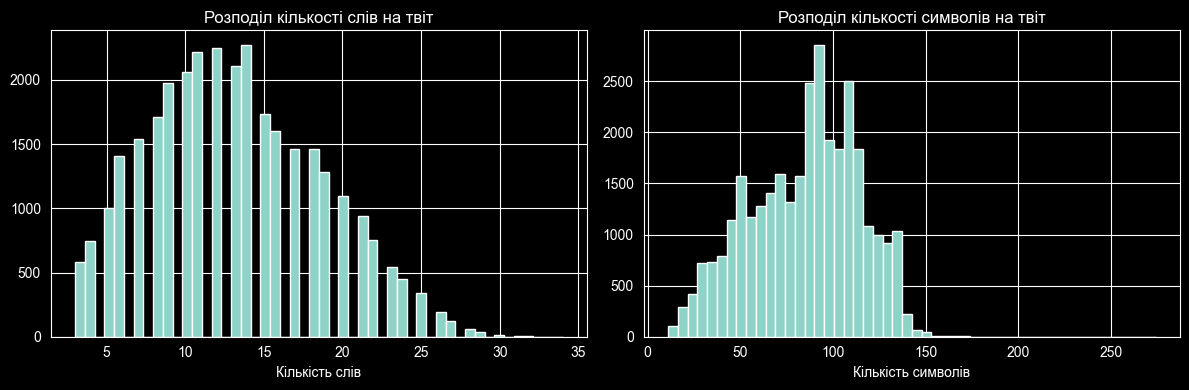

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['word_count'].hist(ax=axes[0], bins=50)
axes[0].set_title('Розподіл кількості слів на твіт')
axes[0].set_xlabel('Кількість слів')
df['char_count'].hist(ax=axes[1], bins=50)
axes[1].set_title('Розподіл кількості символів на твіт')
axes[1].set_xlabel('Кількість символів')
plt.tight_layout()
plt.show()

## Частотність слів по класах

C:\Users\oleks\AppData\Local\Temp\ipykernel_4760\138498392.py:29: UserWarning: Glyph 128 (\x80) missing from font(s) Arial.
  plt.tight_layout()
G:\Stuff\University shit\MLOPS\laba1_v2\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


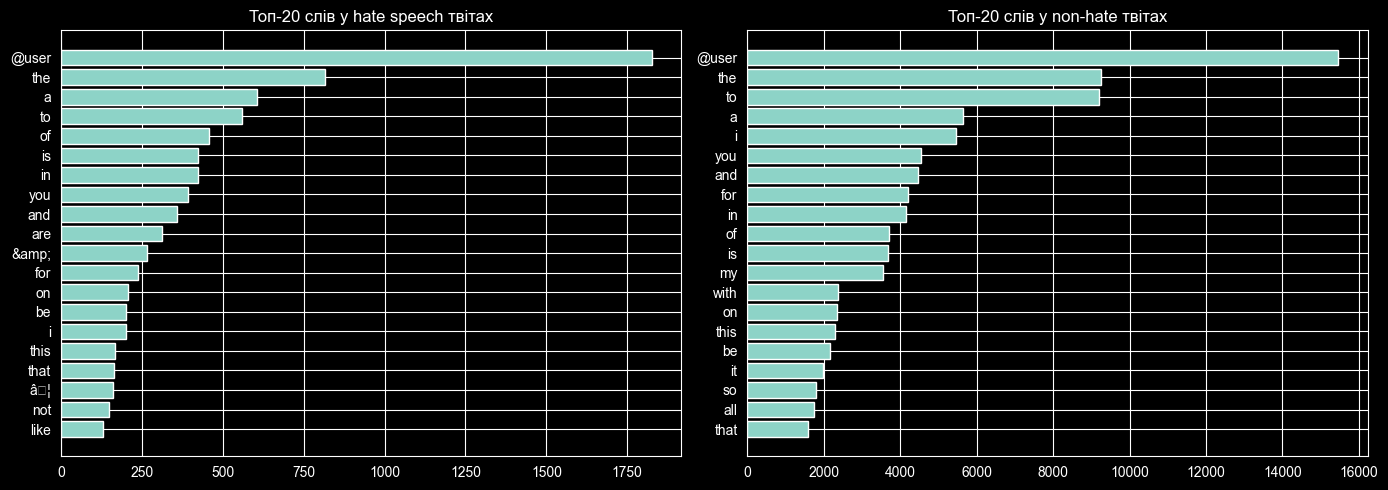

In [8]:
from collections import Counter

def get_top_words(series, n=20):
    all_words = []
    for text in series.astype(str):
        all_words.extend(text.lower().split())
    return Counter(all_words).most_common(n)

hate_tweets = df[df[label_col] == 1][text_col]
non_hate_tweets = df[df[label_col] == 0][text_col]

top_hate = get_top_words(hate_tweets)
top_non_hate = get_top_words(non_hate_tweets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
words_hate, counts_hate = zip(*top_hate)
axes[0].barh(range(len(words_hate)), counts_hate)
axes[0].set_yticks(range(len(words_hate)))
axes[0].set_yticklabels(words_hate)
axes[0].invert_yaxis()
axes[0].set_title('Топ-20 слів у hate speech твітах')

words_non, counts_non = zip(*top_non_hate)
axes[1].barh(range(len(words_non)), counts_non)
axes[1].set_yticks(range(len(words_non)))
axes[1].set_yticklabels(words_non)
axes[1].invert_yaxis()
axes[1].set_title('Топ-20 слів у non-hate твітах')
plt.tight_layout()
plt.show()

## Приклади твітів

In [9]:
print('=== Приклади HATE (label=1) ===')
for i, row in df[df[label_col] == 1].head(5).iterrows():
    print(row[text_col][:100])
    print('---')

print('\n=== Приклади NON-HATE (label=0) ===')
for i, row in df[df[label_col] == 0].head(5).iterrows():
    print(row[text_col][:100])
    print('---')

=== Приклади HATE (label=1) ===
@user #cnn calls #michigan middle school 'build the wall' chant '' #tcot  
---
no comment!  in #australia   #opkillingbay #seashepherd #helpcovedolphins #thecove  #helpcovedolphin
---
retweet if you agree! 
---
@user @user lumpy says i am a . prove it lumpy.
---
it's unbelievable that in the 21st century we'd need something like this. again. #neverump  #xenopho
---

=== Приклади NON-HATE (label=0) ===
 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #r
---
@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #d
---
  bihday your majesty
---
#model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
---
 factsguide: society now    #motivation
---
